In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

import SysSimX
from SysSimX.utilities.units import ureg
from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from MyModels.FEM.fem_pendulum import FEMPendulum
import MyModels.FEM.pendulum_config as fem_config
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum
from MyModels.MasterPendulum.master_pendulum import MasterPendulum

In [2]:
fmu_pendulum_path = Path.cwd().parent / 'FMUs/Pendulum.fmu'

eqb_pendulum     = FMUComponent(name="EQB_Pendulum", fmu_path=fmu_pendulum_path)
fem_pendulum     = FEMPendulum(name="FEM_Pendulum")
opensim_pendulum = OpenSimPendulum(name="OpenSim_Pendulum")

In [3]:
init_params = fem_config.InitialConditionParameters()
init_params.angular_position_deg = 15  # degrees
init_params.drive_torque = 0  # Nm
print(init_params)

sim_params = fem_config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 2.0
sim_params.with_contact = True
sim_params.use_gravity = True
print(sim_params)

contact_params = fem_config.ContactParameters()
contact_params.kn = 1e10
print(contact_params)

fem_pendulum.set_parameters(init_params=init_params,
                            sim_params=sim_params,
                            contact_params=contact_params)

Initial Conditions:
  Angular Position:     15 deg
  Angular Velocity:     0 rad/s
  Drive Torque:         0 Nm
Simulation Parameters:
  Simulation Start Time: 0.0 s
  Internal Time Step:    0.01 s
  Simulation End Time:   2.0 s
  Max Solver Error:      1e-06
  Max Solver Iterations: 20
  Use Gravity:           True
  With Contact:          True
  Torque Traction Dist.: linear
Contact Parameters:
   Contact Stiffness: 1.00e+10 N/m


In [4]:
pendulum = MasterPendulum(
    fem_comp=fem_pendulum,
    opensim_comp=opensim_pendulum,
    fmu_comp=eqb_pendulum
)

t = 0.0
dt = 0.01

pendulum.initialize(t)
pendulum.setup_monitoring()
pendulum.display_monitoring()

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [5]:
t = 0
tf = fem_pendulum.sim_params.t_end
dt = fem_pendulum.sim_params.tau

while t < tf:
    pendulum.do_step(t, dt)
    t += dt

[Pendulum] Switching: EQB to OpenSim @ t=0.0500s
[Pendulum] Switching: OpenSim to FEM @ t=0.3300s
[Pendulum] Switching: FEM to OpenSim @ t=0.5100s
[Pendulum] Switching: OpenSim to FEM @ t=1.1600s


/home/flo/miniconda3/envs/EnvSysSimX/lib/python3.11/site-packages/jupyter_client/session.py:721: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


KeyboardInterrupt: 

In [ ]:
from tabulate import tabulate

print("\n" + "="*60)
print("STATE SYNCHRONIZATION EVENTS")
print("="*60)

for i, synch_event in enumerate(pendulum.sync_events):
    time = synch_event['time']
    from_mode = synch_event['from_mode']
    to_mode = synch_event['to_mode']
    state_retrieved = synch_event['retrieved']
    state_now = synch_event['now']

    print(f"\nEvent {i+1}: t = {time:.4f} s | {from_mode} → {to_mode}")
    
    # Prepare data for table
    table_data = []
    
    # Position
    q_retrieved = state_retrieved['q']['value']
    q_now = state_now['q']['value']
    q_diff = q_now - q_retrieved
    table_data.append(['q (rad)', f'{q_retrieved:.6e}', f'{q_now:.6e}', f'{q_diff:.6e}'])
    
    # Velocity
    omega_retrieved = state_retrieved['omega']['value']
    omega_now = state_now['omega']['value']
    omega_diff = omega_now - omega_retrieved
    table_data.append(['omega (rad/s)', f'{omega_retrieved:.6e}', f'{omega_now:.6e}', f'{omega_diff:.6e}'])
    
    # Acceleration
    alpha_retrieved = state_retrieved['alpha']['value']
    alpha_now = state_now['alpha']['value']
    alpha_diff = alpha_now - alpha_retrieved
    table_data.append(['alpha (rad/s²)', f'{alpha_retrieved:.6e}', f'{alpha_now:.6e}', f'{alpha_diff:.6e}'])
    
    # Torque
    torque_retrieved = state_retrieved['torque']['value']
    torque_now = state_now['torque']['value']
    torque_diff = torque_now - torque_retrieved
    table_data.append(['torque (Nm)', f'{torque_retrieved:.6e}', f'{torque_now:.6e}', f'{torque_diff:.6e}'])
    
    headers = ['Variable', 'Retrieved', 'Current', 'Difference']
    print(tabulate(table_data, headers=headers, tablefmt='grid'))

print("\n" + "="*60)


STATE SYNCHRONIZATION EVENTS

Event 1: t = 0.0500 s | EQB → OpenSim
+----------------+-------------+-----------+--------------+
| Variable       |   Retrieved |   Current |   Difference |
+================+=============+===========+==============+
| q (rad)        |    0.171379 |  0.171379 |  0           |
+----------------+-------------+-----------+--------------+
| omega (rad/s)  |   -0.125763 | -0.125763 |  0           |
+----------------+-------------+-----------+--------------+
| alpha (rad/s²) |   -2.48515  | -2.48515  |  4.44089e-16 |
+----------------+-------------+-----------+--------------+
| torque (Nm)    |    0        |  0        |  0           |
+----------------+-------------+-----------+--------------+



In [ ]:
t_vals_os, q_vals_os = zip(*pendulum._opensim_comp.outputs['q'].history)
t_vals_eqb, q_vals_eqb = zip(*pendulum._fmu_comp.outputs['q'].history)
t_vals_fem, q_vals_fem = zip(*pendulum._fem_comp.outputs['q'].history)

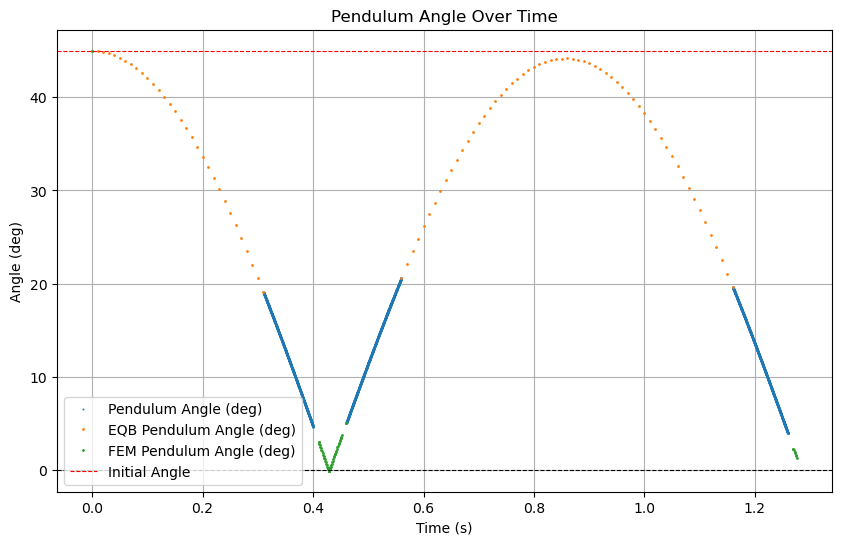

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t_vals_os, np.rad2deg(q_vals_os), label='Pendulum Angle (deg)', linestyle='None', marker='.', markersize=1)
plt.plot(t_vals_eqb[:-6], np.rad2deg(q_vals_eqb[:-6]), label='EQB Pendulum Angle (deg)', linestyle='None', marker='.', markersize=2)
plt.plot(t_vals_fem[:-25], np.rad2deg(q_vals_fem[:-25]), label='FEM Pendulum Angle (deg)', linestyle='None', marker='.', markersize=2)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.axhline(fem_pendulum.init_params.angular_position_deg, color='r', linestyle='--', linewidth=0.8, label='Initial Angle')
plt.title('Pendulum Angle Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Angle (deg)')
plt.grid(True)
plt.legend()
plt.show()